# 06. Data Quality Controls
**Engineering Data Processing with Python** | one-day course | approx. 50 minutes

> **SOLUTION NOTEBOOK.** Every blank and TODO is filled in. Try the exercise version first; use this when you are stuck or to compare approaches. There is usually more than one correct answer.


In [1]:
# ===================== SETUP: run this cell first (click it, then Shift+Enter) =====================
# It makes sure the course data is available in this Colab session and loads the tools we need.
import os, zipfile, urllib.request
from pathlib import Path

DATA_ZIP_URL = ""   # if your trainer gives you a download link for data.zip, paste it between the quotes

def get_course_data():
    if Path("data").is_dir():
        print("Data folder found:", sorted(p.name for p in Path("data").iterdir())[:20])
        return
    if not Path("data.zip").exists() and DATA_ZIP_URL:
        print("Downloading course data...")
        urllib.request.urlretrieve(DATA_ZIP_URL, "data.zip")
    zip_path = Path("data.zip")
    if not zip_path.exists():
        try:
            from google.colab import files
            print("Choose data.zip from your computer (your trainer will tell you where it is).")
            uploaded = files.upload()
            zip_path = Path(next(iter(uploaded)))
        except ImportError:
            raise FileNotFoundError("Put data.zip or the data folder next to this notebook.")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(".")
    print("Data ready:", sorted(p.name for p in Path("data").iterdir()))

get_course_data()
Path("outputs").mkdir(exist_ok=True)

import pandas as pd
import numpy as np
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

def check(condition, ok="Looks right.", hint="Not quite yet. Re-read the instructions above the cell."):
    """Tiny self-check helper used throughout the course."""
    print(("PASS: " + ok) if condition else ("NOT YET: " + hint))

Data folder found: ['3dprinter.csv', 'asset_register.xlsx', 'boiler.json', 'capstone', 'checkpoints', 'concrete.csv', 'manifest.TXT', 'manifest.csv', 'sensor_readings.csv', 'steel.csv', 'thermal-profiles.xlsx', 'work_orders_cmms.csv', 'work_orders_legacy.xlsx']


## What you will do

Cleaning fixes what you know about. Quality controls catch what you did not expect, every time the data is
refreshed. You will:

1. Write validation rules for the work orders as data, not as scattered `if` statements.
2. Split them into **errors** (exclude from KPIs) and **warnings** (report, keep).
3. Add hard stops (`assert`) for problems that mean the whole run is untrustworthy.
4. Check sensor data: sentinels, units, duplicates, gaps, ranges.
5. Add simple anomaly flags: spikes, stuck sensors, threshold alarms.
6. Log what happened so the run can be audited.

In [2]:
DATES = ["date_raised", "date_closed", "last_modified"]
wo = pd.read_csv("data/checkpoints/m05_work_orders_combined.csv", parse_dates=DATES)
print(wo.shape)
wo["asset_status"].value_counts()

(1366, 22)


asset_status
In Service        1321
Decommissioned      39
Unknown asset        6
Name: count, dtype: int64

## 1. Validation rules as data

Each rule is a True/False Series where **True means a problem**. Keeping them in a dictionary means you can
count them, report them and add new ones in one place.

### Exercise 6.1 [Level 1: fill the blanks]

In [3]:
AS_OF = pd.Timestamp("2026-09-30")     # the date of the export; "today" for this data

rules = {
    "closed_before_raised": wo["date_closed"] < wo["date_raised"],
    "negative_hours":       wo["labour_hours"] < 0,
    "implausible_hours":    wo["labour_hours"] > 80,
    "closed_without_date":  (wo["status"] == "Closed") & wo["date_closed"].isna(),
    "unknown_asset":        wo["asset_status"] == "Unknown asset",
    "negative_cost":        wo["parts_cost_eur"] < 0,
    "missing_hours":        wo["labour_hours"].isna(),
}
for name, flagged in rules.items():
    print(f"{name:22} {flagged.sum():4d}")

closed_before_raised      6
negative_hours            4
implausible_hours         3
closed_without_date       5
unknown_asset             6
negative_cost             1
missing_hours            33


In [4]:
check(rules["closed_before_raised"].sum() == 6 and rules["implausible_hours"].sum() == 3 and rules["unknown_asset"].sum() == 6,
      "Rules are catching the planted problems.", "Check the comparison operators and thresholds.")

PASS: Rules are catching the planted problems.


Why 80 hours? It is a judgement: longer than any single job Kilbrack's planners would expect without splitting it.
Write thresholds down as named settings, never as magic numbers buried in code. In Module 07 they move into a
config file.

Note that comparisons with a missing value give `False`. An open job with no closed date is **not** flagged as
"closed before raised". That is what we want here, but be aware of it.

### Exercise 6.2 [Level 2: finish the code]
Add two more rules:
* `open_too_long`: status is not `"Closed"` and the job was raised more than 60 days before `AS_OF`.
* `missing_cost`: `parts_cost_eur` is missing.

In [5]:
rules["open_too_long"] = (wo["status"] != "Closed") & ((AS_OF - wo["date_raised"]).dt.days > 60)
rules["missing_cost"] = wo["parts_cost_eur"].isna()

print(len(rules), "rules")

9 rules


In [6]:
check(len(rules) == 9 and "open_too_long" in rules and rules["missing_cost"].sum() > 0,
      "Nine rules.", "Expected nine rules including open_too_long and missing_cost.")

PASS: Nine rules.


## 2. Errors and warnings

Not every problem is equal.

* **Error**: the row is wrong and would distort a KPI. Exclude it from the KPI dataset, send it back for correcting.
* **Warning**: worth knowing, but the row is still usable (a missing cost does not stop you counting jobs).

### Exercise 6.3 [Level 1: fill the blanks]

In [7]:
ERRORS = ["closed_before_raised", "negative_hours", "implausible_hours", "closed_without_date", "unknown_asset"]

flags = pd.DataFrame(rules)                                         # one True/False column per rule
wo["dq_issues"] = flags.apply(lambda row: ", ".join(row.index[row]), axis=1)
wo["dq_error"] = flags[ERRORS].any(axis=1)                       # True if ANY error rule fired

report = pd.DataFrame({
    "rule": flags.columns,
    "severity": ["error" if r in ERRORS else "warning" for r in flags.columns],
    "rows_flagged": flags.sum().values,
})
report["pct"] = (report["rows_flagged"] / len(wo) * 100).round(2)
report.sort_values(["severity", "rows_flagged"], ascending=[True, False])

,rule,severity,rows_flagged,pct
0,closed_before_raised,error,6,0.44
4,unknown_asset,error,6,0.44
3,closed_without_date,error,5,0.37
1,negative_hours,error,4,0.29
2,implausible_hours,error,3,0.22
8,missing_cost,warning,88,6.44
6,missing_hours,warning,33,2.42
7,open_too_long,warning,9,0.66
5,negative_cost,warning,1,0.07


In [8]:
print("Rows with at least one error:", wo["dq_error"].sum(), "of", len(wo))
wo.loc[wo["dq_error"], ["wo_id", "asset_id", "status", "date_raised", "date_closed", "labour_hours", "dq_issues"]].head(10)

Rows with at least one error: 24 of 1366


,wo_id,asset_id,status,date_raised,date_closed,labour_hours,dq_issues
35,WO-25-00035,CNV-021,Closed,2025-01-29 11:50:00,2025-01-30 22:28:00,1.0,unknown_asset
69,WO-25-00070,CNC-007,Closed,2025-02-16 17:50:00,2025-02-01 17:50:00,4.5,closed_before_raised
144,WO-25-00145,HYP-001,Closed,2025-03-31 16:05:00,2025-03-06 16:05:00,NaN,"closed_before_raised, missing_hours, missing_cost"
154,WO-25-00155,PMP-020,Closed,2025-04-06 16:45:00,2025-04-08 05:40:00,1.5,unknown_asset
294,WO-25-00295,PMP-001,Closed,2025-07-09 17:20:00,2025-07-10 14:01:00,240.0,implausible_hours
326,WO-25-00327,PMP-001,Closed,2025-07-26 06:45:00,2025-07-27 14:54:00,-2.5,negative_hours
362,WO-25-00363,PMP-006,Closed,2025-08-23 12:45:00,NaT,1.5,closed_without_date
377,WO-25-00378,PMP-005,Closed,2025-08-31 13:10:00,2025-08-12 13:10:00,5.0,"closed_before_raised, missing_cost"
387,WO-25-00388,CNC-010,Closed,2025-09-06 17:20:00,NaT,1.5,"closed_without_date, missing_cost"
470,WO-25-00471,CNC-007,Closed,2025-10-21 08:30:00,NaT,2.0,closed_without_date


In [9]:
kpi_ready = wo[~wo["dq_error"]]
report.to_csv("outputs/dq_report.csv", index=False)
wo[wo["dq_issues"] != ""].to_csv("outputs/dq_issues.csv", index=False)
kpi_ready.to_csv("outputs/work_orders_kpi_ready.csv", index=False)
print(len(wo), "rows ->", len(kpi_ready), "KPI-ready rows")

1366 rows -> 1342 KPI-ready rows


In [10]:
check(len(kpi_ready) == len(wo) - wo["dq_error"].sum() and kpi_ready["dq_error"].sum() == 0,
      "KPI dataset excludes error rows. Problem rows are saved for someone to fix.",
      "kpi_ready should contain only rows where dq_error is False.")

PASS: KPI dataset excludes error rows. Problem rows are saved for someone to fix.


## 3. Hard stops: `assert`

Some problems mean the whole run cannot be trusted: duplicate IDs, a date column that failed to parse, a work order
type nobody has mapped. For those you want the pipeline to **stop**, loudly, rather than produce a report.

`assert condition, "message"` does nothing if the condition is True and stops with the message if it is False.

### Exercise 6.4 [Level 1: fill the blanks]

In [11]:
assert wo["wo_id"].is_unique, "Duplicate work order IDs: dedup step failed"
assert wo["date_raised"].notna().all(), "Some work orders have no raised date: date parsing failed"
assert set(wo["wo_type"]) <= {"PM", "CM", "INSP"}, f"Unexpected work order types: {set(wo['wo_type'])}"
print("All hard checks passed.")

All hard checks passed.


Rule of thumb: **assert** on structure (IDs, types, required columns). **Flag** on content (individual bad rows).

## 4. Sensor data

Condition monitoring from three compressors and three pumps, every 10 minutes, 1 to 21 August 2026.

In [12]:
sens = pd.read_csv("data/sensor_readings.csv", parse_dates=["timestamp"])
print(sens.shape)
print(sens.groupby("asset_id")[["temp_unit", "pressure_unit"]].first())
sens.describe()

(18148, 8)
         temp_unit pressure_unit
asset_id                        
CMP-001          C           bar
CMP-002          C           bar
CMP-003          F           bar
PMP-001          C           bar
PMP-002          C           bar
PMP-004          C           kPa


,timestamp,bearing_temp,vibration_mm_s,discharge_pressure
count,18148,18148.000000,18148.000000,18058.000000
mean,2026-08-11 11:45:41.657483008,67.681693,9.068940,61.482777
min,2026-08-01 00:00:00,-999.000000,0.000000,0.000000
25%,2026-08-06 06:00:00,54.440000,2.068000,3.465000
50%,2026-08-11 11:50:00,60.060000,2.344000,7.437000
75%,2026-08-16 17:50:00,63.940000,2.634000,7.613000
max,2026-08-21 23:50:00,153.400000,9999.000000,378.326000
std,NaN,66.049143,256.979154,124.780207


Look at the describe output: a minimum temperature of -999 and a maximum vibration of 9999. Those are **sentinel
values**: the logger's way of saying "no reading". Left in, they wreck every average and trigger every alarm.

### Exercise 6.5 [Level 1: fill the blanks]  Sentinels and duplicates

In [13]:
SENTINELS = [-999, 9999]
for col in ["bearing_temp", "vibration_mm_s", "discharge_pressure"]:
    sens[col] = sens[col].replace(SENTINELS, np.nan)

n = len(sens)
sens = sens.drop_duplicates(subset=["timestamp", "asset_id"])
print("Duplicate readings removed:", n - len(sens))
sens.describe()

Duplicate readings removed: 40


,timestamp,bearing_temp,vibration_mm_s,discharge_pressure
count,18108,18053.000000,18096.000000,18018.000000
mean,2026-08-11 11:58:13.240556544,70.942639,2.459640,61.611731
min,2026-08-01 00:00:00,21.120000,0.000000,0.000000
25%,2026-08-06 05:40:00,54.470000,2.068000,3.466000
50%,2026-08-11 12:25:00,60.070000,2.345000,7.438000
75%,2026-08-16 18:10:00,63.950000,2.634000,7.613000
max,2026-08-21 23:50:00,153.400000,16.394000,378.326000
std,NaN,30.135098,1.043179,124.888590


In [14]:
check(sens["bearing_temp"].min() > -100 and sens["vibration_mm_s"].max() < 100 and not sens.duplicated(["timestamp", "asset_id"]).any(),
      "Sentinels gone, one reading per asset per timestamp.", "Check the sentinel list and the subset for duplicates.")

PASS: Sentinels gone, one reading per asset per timestamp.


### Exercise 6.6 [Level 2: finish the code]  Units
One logger reports temperature in °F, another reports pressure in kPa (see the unit columns). Convert to °C and bar
**only on those rows**, then update the unit columns.

* `mask = sens["temp_unit"] == "F"` picks the rows.
* `sens.loc[mask, "bearing_temp"] = ...` changes only those rows.
* °C = (°F - 32) x 5/9.  1 bar = 100 kPa.

In [15]:
f_rows = sens["temp_unit"] == "F"
sens.loc[f_rows, "bearing_temp"] = (sens.loc[f_rows, "bearing_temp"] - 32) * 5 / 9
sens.loc[f_rows, "temp_unit"] = "C"

kpa_rows = sens["pressure_unit"] == "kPa"
sens.loc[kpa_rows, "discharge_pressure"] = sens.loc[kpa_rows, "discharge_pressure"] / 100
sens.loc[kpa_rows, "pressure_unit"] = "bar"

sens.groupby("asset_id")[["bearing_temp", "discharge_pressure"]].median()

,bearing_temp,discharge_pressure
asset_id,,
CMP-001,58.960000,7.48500
CMP-002,57.950000,7.49400
CMP-003,58.011111,7.49300
PMP-001,57.930000,3.40000
PMP-002,57.920000,3.40200
PMP-004,57.920000,3.39802


In [16]:
med = sens.groupby("asset_id")["bearing_temp"].median()
check((sens["temp_unit"] == "C").all() and (sens["pressure_unit"] == "bar").all() and med.between(40, 80).all(),
      "One unit per column, and every asset's median bearing temperature is now similar. That is the engineering check.",
      "Some rows still in F or kPa, or a conversion is wrong.")

PASS: One unit per column, and every asset's median bearing temperature is now similar. That is the engineering check.


### Exercise 6.7 [Level 2: finish the code]  Gaps
Readings should arrive every 10 minutes. Find gaps longer than that, per asset.
`groupby("asset_id")["timestamp"].diff()` gives the time since the previous reading **of the same asset**.

In [17]:
sens = sens.sort_values(["asset_id", "timestamp"]).reset_index(drop=True)
sens["since_last"] = sens.groupby("asset_id")["timestamp"].diff()
gaps = sens[sens["since_last"] > pd.Timedelta(minutes=10)]

gaps[["asset_id", "timestamp", "since_last"]]

,asset_id,timestamp,since_last
4356,CMP-002,2026-08-10 12:00:00,0 days 06:10:00


In [18]:
check(len(gaps) == 1 and gaps["asset_id"].iloc[0] == "CMP-002",
      "One 6-hour gap on CMP-002. A report averaging 'August' for that asset is missing 6 hours.",
      "Expected one gap on CMP-002.")

PASS: One 6-hour gap on CMP-002. A report averaging 'August' for that asset is missing 6 hours.


## 5. Simple anomaly flags

Three flags, each simple enough to explain to a maintenance manager in one sentence:

| Flag | Rule | Catches |
|---|---|---|
| `spike` | Reading is more than 5 mm/s away from the median of its neighbours | Single bad readings, electrical noise |
| `stuck` | Exactly the same value for an hour while the machine is running | Frozen sensor or logger |
| `alarm` | Vibration above 7.1 mm/s (illustrative limit) | Real machine problems |

Spike and stuck flags are about **data quality**. Alarm is about the **machine**. Keep them separate:
you do not want a frozen sensor raising a work order, or a real alarm being filtered out as "noise".

### Exercise 6.8 [Level 2: finish the code]
The rolling median is written for you. Complete `stuck` and `alarm`.

In [19]:
g = sens.groupby("asset_id")["vibration_mm_s"]
rolling_median = g.transform(lambda x: x.rolling(7, center=True, min_periods=3).median())
rolling_std = g.transform(lambda x: x.rolling(6).std())

sens["spike"] = (sens["vibration_mm_s"] - rolling_median).abs() > 5
sens["stuck"] = (rolling_std == 0) & (sens["vibration_mm_s"] > 0.5)
sens["alarm"] = (sens["vibration_mm_s"] > 7.1) & ~sens["spike"]

sens.groupby("asset_id")[["spike", "stuck", "alarm"]].sum()

,spike,stuck,alarm
asset_id,,,
CMP-001,0,0,311
CMP-002,0,0,0
CMP-003,0,0,0
PMP-001,3,0,0
PMP-002,0,43,0
PMP-004,3,0,0


In [20]:
counts = sens.groupby("asset_id")[["spike", "stuck", "alarm"]].sum()
check(counts.loc["PMP-002", "stuck"] > 30 and counts["alarm"].drop("CMP-001").sum() == 0 and counts.loc["CMP-001", "alarm"] > 0,
      "Stuck sensor on PMP-002, spikes on the pumps, and real alarms only on CMP-001.",
      "Check the stuck and alarm conditions.")

PASS: Stuck sensor on PMP-002, spikes on the pumps, and real alarms only on CMP-001.


### Did the data see the failure coming?

The CMMS has a corrective work order on **CMP-001** raised 18 Aug 2026 14:20: *compressor tripped, bearing failure*.

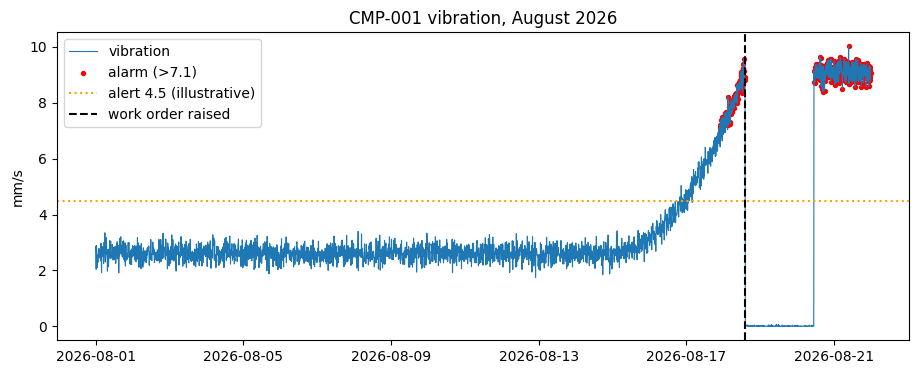

First reading above 4.5 mm/s: 2026-08-16 19:40:00 (43 h before the trip)
First alarm above 7.1 mm/s:   2026-08-17 21:40:00 (17 h before the trip)


In [21]:
import matplotlib.pyplot as plt

WO_RAISED = pd.Timestamp("2026-08-18 14:20")
cmp1 = sens[sens["asset_id"] == "CMP-001"].set_index("timestamp")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cmp1.index, cmp1["vibration_mm_s"], lw=0.8, label="vibration")
ax.scatter(cmp1.index[cmp1["alarm"]], cmp1.loc[cmp1["alarm"], "vibration_mm_s"], color="red", s=8, label="alarm (>7.1)")
ax.axhline(4.5, ls=":", color="orange", label="alert 4.5 (illustrative)")
ax.axvline(WO_RAISED, color="black", ls="--", label="work order raised")
ax.set_ylabel("mm/s"); ax.set_title("CMP-001 vibration, August 2026"); ax.legend(loc="upper left")
plt.show()

first_alert = cmp1.index[cmp1["vibration_mm_s"] > 4.5].min()
first_alarm = cmp1.index[cmp1["alarm"]].min()
print("First reading above 4.5 mm/s:", first_alert, f"({(WO_RAISED - first_alert).total_seconds() / 3600:.0f} h before the trip)")
print("First alarm above 7.1 mm/s:  ", first_alarm, f"({(WO_RAISED - first_alarm).total_seconds() / 3600:.0f} h before the trip)")

The vibration climbed for days. A lower alert threshold gives more warning, at the price of more false alerts on
other machines. That trade-off is an engineering decision, not a data one. The data's job is to make the evidence
visible and trustworthy, which is why the sentinel, unit and stuck-sensor work above matters: without it, the
`9999` readings would have fired alarms on healthy machines and nobody would trust the real one.

## 6. Logging: a record of what the run did

`print` disappears when the session ends. A **log file** stays with the outputs and tells the next person
(or you, in three months) what happened.

### Exercise 6.9 [Level 1: fill the blanks]

In [22]:
import logging, sys

log = logging.getLogger("kilbrack_dq")
log.setLevel(logging.INFO)
log.handlers.clear()
file_handler = logging.FileHandler("outputs/quality.log", mode="w")
file_handler.setFormatter(logging.Formatter("%(asctime)s %(levelname)-7s %(message)s"))
log.addHandler(file_handler)
log.addHandler(logging.StreamHandler(sys.stdout))   # also show messages in the notebook

log.info(f"Work orders checked: {len(wo)}")
for _, r in report.iterrows():
    if r["rows_flagged"] > 0:
        level = log.warning if r["severity"] == "error" else log.info
        level(f"Rule {r['rule']}: {r['rows_flagged']} rows ({r['pct']}%)")
log.info(f"Sensor gaps found: {len(gaps)}")
log.info(f"Stuck sensor readings: {int(sens['stuck'].sum())}, spikes: {int(sens['spike'].sum())}, alarms: {int(sens['alarm'].sum())}")

Work orders checked: 1366


Rule closed_before_raised: 6 rows (0.44%)


Rule negative_hours: 4 rows (0.29%)


Rule implausible_hours: 3 rows (0.22%)


Rule closed_without_date: 5 rows (0.37%)


...

Rule missing_hours: 33 rows (2.42%)


Rule open_too_long: 9 rows (0.66%)


Rule missing_cost: 88 rows (6.44%)


Sensor gaps found: 1


Stuck sensor readings: 43, spikes: 6, alarms: 311


In [23]:
print(open("outputs/quality.log").read())

2026-10-06 13:42:49,728 INFO    Work orders checked: 1366
2026-10-06 13:42:49,729 WARNING Rule closed_before_raised: 6 rows (0.44%)
2026-10-06 13:42:49,729 WARNING Rule negative_hours: 4 rows (0.29%)
2026-10-06 13:42:49,730 WARNING Rule implausible_hours: 3 rows (0.22%)
2026-10-06 13:42:49,730 WARNING Rule closed_without_date: 5 rows (0.37%)
2026-10-06 13:42:49,731 WARNING Rule unknown_asset: 6 rows (0.44%)
2026-10-06 13:42:49,731 INFO    Rule negative_cost: 1 rows (0.07%)
2026-10-06 13:42:49,732 INFO    Rule missing_hours: 33 rows (2.42%)
2026-10-06 13:42:49,733 INFO    Rule open_too_long: 9 rows (0.66%)
2026-10-06 13:42:49,734 INFO    Rule missing_cost: 88 rows (6.44%)
2026-10-06 13:42:49,734 INFO    Sensor gaps found: 1
2026-10-06 13:42:49,735 INFO    Stuck sensor readings: 43, spikes: 6, alarms: 311



In [24]:
sens.drop(columns="since_last").to_csv("outputs/sensor_readings_clean.csv", index=False)

## Stretch [Level 3: Gemini allowed]

1. Ask Gemini to add a `temp_alarm` flag for bearing temperature rising more than 10 °C above that asset's median.
   Does it fire on CMP-001 before the trip too?
2. Ask Gemini: *"What are the weaknesses of a fixed 7.1 mm/s vibration alarm across different machines?"*
   Compare its answer with what you know about machine classes and ISO 20816. Did it state anything as fact that
   you would want to check in the standard?

## Summary

* Rules as a dictionary of True/False Series: easy to count, report and extend.
* Errors are excluded from KPIs and sent for correction; warnings are reported.
* `assert` for structural problems that should stop the run.
* Sensor data: sentinels to NaN, one unit per column, de-duplicate, check gaps, then flag anomalies.
* Keep data-quality flags (spike, stuck) separate from machine-condition flags (alarm).
* Log counts to a file so every run leaves an audit trail.

Next: **07 Packaging a Repeatable Processing Script**.